cell 1 -## Random Forest for Cancer Drug Response Prediction (CTRPv2, LCO splits)

# What does this notebook do?
- Loads cell features using cell-line view (gene expression, reduced to fixed gene list)
-And drug features using drug views (128-bit PubChem fingerprint)
- Two separate feature reservoirs, concatenated only at model-input time
- Loads the exisiting 5 individual LCO (leave-cell-line-out) splits.
- Trains and evaluates on the 5 existing LCO splits, then tests
generalisation on GDSC2 cell lines unseen in CTRPv2.

- For each split:
1. Builds the input matrix X by placing the cell-line vector and the drug vector side-by-side (concatenation) for each row.
2. Scales gene expression using arcsinh + StandardScaler. 
Arcsinh reduces the influence of extreme outlier values (a few highly active genes won't dominate the model), and StandardScaler puts all genes on a comparable scale. Both are fit using only the training data, so no information from validation or test leaks in early.
3. Runs a small hyperparameter search using the validation set, trying a few different Random Forest settings and picking the one that predicts validation data best. This avoids randomly guessing settings and instead chooses ones shown to generalise to unseen data.
4. Retrains the final model on the combined training and validation data using the best hyperparameters found, so the model learns from as much data as possible before being evaluated. The test set remains untouched throughout, so the final performance numbers reflect genuinely unseen data.
5. Evluates only on the test set (R2, Pearson, Spearman, MSE)

- Reports metrices per split, and mean/std across the 5 splits.
- Cross-study step: takes the model trained on each CTRPva split and predicts on GDSC2 cell lines that are not present in CTPRv2 at all, to test generalisation to an independent dataset.

This structure mirrors DrEvals SklearnModel/experiment.py, written as plain functions (no DRPModel class for simplicity)

# Input data:
- Clean GDSC2 response file restricted to cell lines unseen in CTRPv2
- Transposed fingerprint files for both CTRPv2 and GDSC2

In [2]:
# cell 2 - Import Libraries

import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print ("Imports completed.")

Imports completed.


In [3]:
# cell 3 - Configuration and folder layout

Data_root = "/Users/manellamukangwa/Honours-Cancer-Drug-Response-Project/Projects/Cancer-Drug-Response-Prediction/data"

CTRPv2_gene_expression = f"{Data_root}/raw/CTRPv2/gene_expression.csv"
CTRPv2_drug_fingerprints = f"{Data_root}/processed/CTRPv2_fingerprints_128_transposed.csv"
CTRPv2_lco_splits_dir = f"{Data_root}/processed/lco_splits"

GDSC2_response_unseen = f"{Data_root}/processed/GDSC2_response_unseen_in_ctrpv2.csv"
GDSC2_gene_expression = f"{Data_root}/raw/GDSC2/gene_expression.csv"
GDSC2_drug_fingerprints = f"{Data_root}/processed/GDSC2_fingerprints_128_transposed.csv"

Gene_list_path = f"{Data_root}/meta/gene_lists/landmark_genes_reduced.csv"

Cell_line_identifier = "cell_line_name"
Drug_identifier = "pubchem_id"
Response_column = "LN_IC50_curvecurator"

n_splits = 5

# DrEval Random Forest hyperparameters
Hyperparam_grid = [
    {
        "n_estimators": 100,
        "max_depth": d,
        "max_samples": 0.2,
        "criterion": "squared_error"
    }
    for d in [5, 10, 30]
]

RF_random_state = 42

print("Completed!")

Completed!


cell 4 - Load the gene expression data turn it into a readable format for the model
- takes two csv files gene_expression.csv and CSV containing the list of genes that will be used.
- loads the gene expression → selects the required genes → checks that they're present → removes duplicate cell lines → converts each cell line's genes into numbers → returns them.
- Use cell line name as the identifier for each cell lines gene expr.
- Remove cellosaurus_id column, remove it because it isn't a gene-expression feature.

In [4]:
# cell 5 -Cell-line features: gene expression view

def load_gene_expression_features (gene_expression_csv, gene_list_csv):
    gene_expression = pd.read_csv(gene_expression_csv ,index_col=Cell_line_identifier)
    gene_expression.index = gene_expression.index.astype(str)
    if "cellosaurus_id" in gene_expression.columns:
        gene_expression = gene_expression.drop(columns = ["cellosaurus_id"])

        gene_list = pd.read_csv(gene_list_csv)["Symbol"].tolist()  # reads gene-list CSV and takes the Symbol column and converts into python list

# Find genes in my selected gene list that don't exist in the gene-expression dataset:

        missing_genes = [g for g in gene_list if g not in gene_expression.columns] # Check whether all required genes exist
        if missing_genes:
            raise ValueError(
                f"{len(missing_genes)} genes from list are missing in "
                f"{gene_expression_csv}. First few missing: {missing_genes [:10]}" # stops and mentions genes that cant be found
            )

# Genes will be exactly like genes found in gene list and remove duplicates:

        gene_expression = gene_expression[gene_list] # Keep only selected genes
        gene_expression = gene_expression [~gene_expression.index.duplicated(keep="first")]

        return {cl: gene_expression.loc[cl].to_numpy(dtype=float)for cl in gene_expression.index} # each cell line gets a numerical vector containing its gene-expression values.

# Call the function
gene_expression_features = load_gene_expression_features(
    CTRPv2_gene_expression,
    Gene_list_path
    )

print("Completed.")

Completed.


cell 6 - The function will load the transposed fingerprint CSV and turn each drug's 128 fingerprint values into a numerical array.

In [5]:
# cell 7 
# Drug features: fingerprint view
def load_drug_fingerprint_features (transposed_fingerprint_csv):
    drug_fingerprint = pd.read_csv (
        transposed_fingerprint_csv, index_col = Drug_identifier # tells pandas which column (pubchem_id) should be used as the identifier for each drug when it reads the CSV.
        ) 
    
    # Create drug fingerprint dictionary:
    drug_fingerprint.index = drug_fingerprint.index.astype(str)
    return {drug: drug_fingerprint.loc[drug].to_numpy(dtype=float) for drug in drug_fingerprint.index} # converts that row into a NumPy array of numbers.

# Call the function:
drug_fingerprint_features = load_drug_fingerprint_features (
    CTRPv2_drug_fingerprints
)

print("Completed.")


Completed.


# cell 8 Contains two functions
- load_spliy_part loads one LCO at a time
- split_dir: where LCO splits files are found
- split_idx: which split is loaded
- part: train validation or test LCO

In [6]:
# cell 9
#  Response data: existing LCO splits + response tables

def load_split_part(splits_dir, split_idx, part):
    path = os.path.join(splits_dir, f"cv_split_{split_idx}_{part}.csv") # Builds the file path
    return pd.read_csv (path, dtype = {Drug_identifier: str, Cell_line_identifier: str}) # Opens the csv file and treat botuh drug and cell id as text

def load_response_table(path): # Loads the drug-response table
    df = pd.read_csv(path,   # Opens drug response csv file
                     dtype ={Drug_identifier: str, Cell_line_identifier: str}, 
                     low_memory=False)
    df = df [[Cell_line_identifier, # from drug response csv keep omly the columnd listed
              Drug_identifier,
              Response_column]]. copy()
    df =df.dropna(subset=[Response_column]) # from drug response csv if row doesn't have an LN_IC50_curvecurator value, remove it.
    df=df.drop_duplicates(subset=[Cell_line_identifier, Drug_identifier]) # Remove duplicate cell-line/drug combinations

    return df

print ("Completed.")

#load_split = load_split_part (
   # splits_dir, 
   # split_idx, 
    # part )

#load_response_table = load_response_table (
    #path)

Completed.


## cell 10 Gene expression scaling: arcsinh, then StandardScaler
- Gene expression preprocessing using arcsinh and StandardScaler
- `items()` is what lets you go through the dictionary's cell-line → gene-expression vector pairs.
- Original gene expression
        ↓
     arcsinh (transforms the distribution of the gene-expression values and reduces the influence of very large values.)
        ↓
Transformed gene expression

- Fit cell lines
      ↓
Calculate mean for each gene
      ↓
Calculate standard deviation for each gene
      ↓
Scaler is now "fitted"


In [7]:
# cell 11 
def arcsinh_transform(gene_expression): # This function applies arcsinh to every gene-expression value.
    return {cl: np.arcsinh(vec) for cl, vec in gene_expression.items()}

def fit_and_scale_gene_expression (gene_expression, fit_cell_lines): # arcsinh → fit StandardScaler → scale all cell lines
    arcsinh_expression = arcsinh_transform(gene_expression) # applies the arcsinh transformation.
    fit_matrix = np.vstack([ # creates a gene expr vecot matric using cell lines from fit_cell_lines
        arcsinh_expression[cl] 
        for cl in fit_cell_lines 
        if cl in arcsinh_expression])
    
    scaler = StandardScaler ()
    scaler.fit(fit_matrix) # scaler calculates the mean and standard deviation for each gene using the fit_cell_lines.
    scaled_expression = { # fitted scaler is applied to every cell line.
        cl: scaler.transform(vec.reshape(1,-1))[0] 
        for cl, vec in arcsinh_expression.items()
        }
    
    return scaled_expression, scaler # function returns: scaled gene-expression data and fitted scaler

def scale_with_fitted_Scaler (gene_expression, scaler):
    arcsinh_expression = arcsinh_transform (gene_expression)
    
    return {
        cl: scaler.transform(vec.reshape(1,-1))[0] 
        for cl, vec in arcsinh_expression.items()
        }

print ("Completed.")


Completed.


## # cell 12 Building the input matrix: concatenating the two views
- point where your cell-line features and drug features are combined to create the model input X, while the drug-response value becomes y
- Create empty lists:  
- X_rows → combined gene + drug features, y_rows → drug-response values, kept_idx → which rows from your original response table were successfully used



In [8]:
# # cell 13 function takes 1. response table containing cl, drug and response
# 2. gene expr features for each cl
# 3. fingpnt for each cl
def build_X_y(df, gene_expression, drug_fingerprints):
    X_rows, y_rows, kept_idx = [], [], [] # Creates empty lists
    for i, row in df.iterrows(): # Go through every response row to look at every row in the response table one at a time.
        cl, drug = row[Cell_line_identifier], row[Drug_identifier]
        if cl not in gene_expression or drug not in drug_fingerprints: # Check that you have features for both because you can't create a model input if one of the two feature sets is missing.
            continue
        X_rows.append(np.concatenate([gene_expression[cl], drug_fingerprints[drug]])) # Combine gene expression + drug fingerprint
        y_rows.append(row[Response_column]) # Store the response value
        kept_idx.append(i) # Remember which rows were successfully used

    X = np.vstack(X_rows) if X_rows else np.empty ((0,)) # stacks all the feature vectors into a matrix.
    y = np.array(y_rows, dtype=float) # turns response values into a numerical array.

    return X, y, df.loc[kept_idx].reset_index(drop=True)

print ("Completed.")

Completed.


## # cell 14 Metrics


In [9]:
# cell 15
def compute_metrics (y_true, y_pred):
    return {
        "R2": r2_score (y_true, y_pred),
        "Pearson": pearsonr(y_true, y_pred)[0],
        "Spearman": spearmanr(y_true, y_pred)[0],
        "MSE": mean_squared_error (y_true, y_pred),
    }

## Load everything once

In [10]:
# cell 16
print("Loading CTRPv2 gene expression features ...")
ctrpv2_gene_expr = load_gene_expression_features(CTRPv2_gene_expression, Gene_list_path)

print("Loading CTRPv2 drug fingerprints (already transposed) ...")
ctrpv2_drug_fingerprints = load_drug_fingerprint_features(CTRPv2_drug_fingerprints)

print("Loading GDSC2 gene expression features ...")
gdsc2_gene_expr = load_gene_expression_features(GDSC2_gene_expression, Gene_list_path)

print("Loading GDSC2 drug fingerprints (already transposed) ...")
gdsc2_drug_fingerprints = load_drug_fingerprint_features(GDSC2_drug_fingerprints)

print("Loading GDSC2 response table (already restricted to cell lines unseen in CTRPv2) ...")
gdsc2_response = load_response_table(GDSC2_response_unseen)

Loading CTRPv2 gene expression features ...


Loading CTRPv2 drug fingerprints (already transposed) ...
Loading GDSC2 gene expression features ...
Loading GDSC2 drug fingerprints (already transposed) ...
Loading GDSC2 response table (already restricted to cell lines unseen in CTRPv2) ...


## # cell 17
Main loop: train, tune, test, and cross-study evaluate on each of the 5 splits

In [11]:
# cell 18 Main loop: train, tune, test, and cross-study evaluate on each of the 5 splits

within_study_results = []
cross_study_results = []
all_predictions = []  # collects per-row actual/predicted values with IDs, for all splits

for split_idx in range (n_splits):
    print (f"\n================= LCO SPLIT {split_idx} =================")

    train_df = load_split_part (CTRPv2_lco_splits_dir, split_idx, "train")
    validation_df = load_split_part (CTRPv2_lco_splits_dir, split_idx, "validation")
    test_df = load_split_part (CTRPv2_lco_splits_dir, split_idx, "test")

    train_cell_lines = train_df [Cell_line_identifier].unique()
    scaled_ctrpv2_gene_expr, _ = fit_and_scale_gene_expression  (ctrpv2_gene_expr, train_cell_lines)

    X_train, y_train, _ = build_X_y (train_df, scaled_ctrpv2_gene_expr, ctrpv2_drug_fingerprints)
    X_val, y_val, _ = build_X_y(validation_df, scaled_ctrpv2_gene_expr, ctrpv2_drug_fingerprints)

    print (f"Train size: {len(y_train)} | Validation size: {len(y_val)}")

    best_params, best_val_mse = None, np.inf
    for params in Hyperparam_grid:
        model = RandomForestRegressor (random_state = RF_random_state,n_jobs=-1, **params)
        model.fit(X_train, y_train)
        val_pred = model.predict (X_val)
        val_mse = mean_squared_error (y_val, val_pred)
        print (f" hyperparams {params} -> validation MSE = {val_mse:.4f}")
        if val_mse < best_val_mse:
            best_val_mse, best_params = val_mse, params

    print (f"Best Hyperparameters: {best_params}")

    trainval_df = pd.concat ([
    train_df, validation_df], 
    ignore_index = True
    )
    trainval_cell_lines = trainval_df[Cell_line_identifier].unique()

    final_scaled_ctrpv2_gene_expr, final_scaler = fit_and_scale_gene_expression (
    ctrpv2_gene_expr, trainval_cell_lines
    )

    X_trainval, y_trainval, _ = build_X_y (trainval_df, final_scaled_ctrpv2_gene_expr, ctrpv2_drug_fingerprints)
    final_model = RandomForestRegressor (random_state= RF_random_state,n_jobs=-1, **best_params)
    final_model.fit(X_trainval, y_trainval)

    X_test, y_test, test_kept_df = build_X_y (test_df, final_scaled_ctrpv2_gene_expr, ctrpv2_drug_fingerprints)  # <<< CHANGED: was "_", now keeps the row-id dataframe
    test_pred = final_model.predict (X_test)
    test_metrics = compute_metrics (y_test, test_pred)
    test_metrics["split"] = split_idx

    within_study_results.append(test_metrics)
    print(f"Test metrics (within-study, CTRPv2): {test_metrics}")

    all_predictions.append(pd.DataFrame({  # Store per-row actual/predicted + IDs for this split
        "dataset": "CTRPv2",
        "split": split_idx,
        "cell_line_id": test_kept_df[Cell_line_identifier].values,
        "drug_id": test_kept_df[Drug_identifier].values,
        "y_actual": y_test,
        "y_predicted": test_pred,
    }))  

    gdsc2_scaled_gene_expression = scale_with_fitted_Scaler (gdsc2_gene_expr, final_scaler)
    X_gdsc2, y_gdsc2, gdsc2_kept_df = build_X_y (gdsc2_response, gdsc2_scaled_gene_expression, gdsc2_drug_fingerprints)  # <<< CHANGED: was "_", now keeps the row-id dataframe

    if len(y_gdsc2) > 0:
        gdsc2_pred = final_model.predict(X_gdsc2)
        gdsc2_metrics = compute_metrics (y_gdsc2, gdsc2_pred)
        all_predictions.append(pd.DataFrame({  # store per-row actual/predicted + IDs for this split
            "dataset": "GDSC2",
            "split": split_idx,
            "cell_line_id": gdsc2_kept_df[Cell_line_identifier].values,
            "drug_id": gdsc2_kept_df[Drug_identifier].values,
            "y_actual": y_gdsc2,
            "y_predicted": gdsc2_pred,
        })) 
    else:
        gdsc2_metrics = {"R2": np.nan, "Pearson": np.nan, "Spearman": np.nan, "MSE": np.nan}
    gdsc2_metrics["split"] = split_idx
    cross_study_results.append(gdsc2_metrics)
    print(f"Cross-study metrics (GDSC2, unseen cell lines): {gdsc2_metrics}")

all_predictions_df = pd.concat(all_predictions, ignore_index=True) # combine all splits/datasets into one table


================= LCO SPLIT 0 =================


Train size: 158227 | Validation size: 17896
 hyperparams {'n_estimators': 100, 'max_depth': 5, 'max_samples': 0.2, 'criterion': 'squared_error'} -> validation MSE = 4.0085
 hyperparams {'n_estimators': 100, 'max_depth': 10, 'max_samples': 0.2, 'criterion': 'squared_error'} -> validation MSE = 1.9065
 hyperparams {'n_estimators': 100, 'max_depth': 30, 'max_samples': 0.2, 'criterion': 'squared_error'} -> validation MSE = 1.7721
Best Hyperparameters: {'n_estimators': 100, 'max_depth': 30, 'max_samples': 0.2, 'criterion': 'squared_error'}
Test metrics (within-study, CTRPv2): {'R2': 0.7327093516572343, 'Pearson': np.float64(0.8567687028290907), 'Spearman': np.float64(0.8492010284762332), 'MSE': 1.7483934636081753, 'split': 0}
Cross-study metrics (GDSC2, unseen cell lines): {'R2': 0.1937459524780324, 'Pearson': np.float64(0.5058395259451619), 'Spearman': np.float64(0.39640296294809485), 'MSE': 5.294263052137797, 'split': 0}

================= LCO SPLIT 1 =================
Train size: 156598 

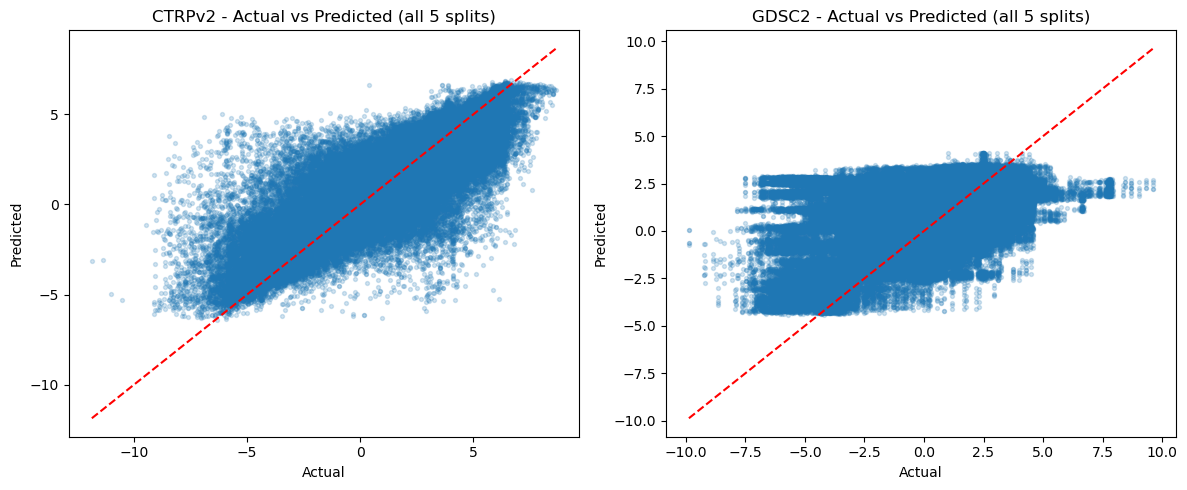

In [12]:
# Actual vs Predicted scatter plot

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, dataset_name in zip(axes, ["CTRPv2", "GDSC2"]):
    subset = all_predictions_df[all_predictions_df["dataset"] == dataset_name]
    ax.scatter(subset["y_actual"], subset["y_predicted"], alpha=0.2, s=8)
    lims = [subset[["y_actual", "y_predicted"]].min().min(), subset[["y_actual", "y_predicted"]].max().max()]
    ax.plot(lims, lims, "r--")
    ax.set_title(f"{dataset_name} - Actual vs Predicted (all 5 splits)")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

## # cell 19 Results summary

In [13]:
# # cell 20
within_df = pd.DataFrame(within_study_results).set_index("split")
cross_df = pd.DataFrame(cross_study_results).set_index("split")

print("================= WITHIN-STUDY RESULTS (CTRPv2) =================")
display(within_df)
print("\nMean across splits:")
display(within_df.mean(numeric_only=True))
print("\nStd across splits:")
display(within_df.std(numeric_only=True))

print("\n================= CROSS-STUDY RESULTS (GDSC2) =================")
display(cross_df)
print("\nMean across splits:")
display(cross_df.mean(numeric_only=True))
print("\nStd across splits:")
display(cross_df.std(numeric_only=True))

================= WITHIN-STUDY RESULTS (CTRPv2) =================


,R2,Pearson,Spearman,MSE
split,,,,
0,0.732709,0.856769,0.849201,1.748393
1,0.735045,0.857761,0.851375,1.709921
2,0.738356,0.859538,0.846922,1.665535
3,0.742544,0.862086,0.856797,1.650015
4,0.711107,0.843376,0.836598,1.864574



Mean across splits:


R2          0.731952
Pearson     0.855906
Spearman    0.848179
MSE         1.727688
dtype: float64


Std across splits:


...

,R2,Pearson,Spearman,MSE
split,,,,
0,0.193746,0.505840,0.396403,5.294263
1,0.225796,0.524678,0.395325,5.083805
2,0.261762,0.524404,0.417416,4.847634
3,0.219612,0.510974,0.403026,5.124417
4,0.215540,0.523807,0.416846,5.151155



Mean across splits:


R2          0.223291
Pearson     0.517940
Spearman    0.405803
MSE         5.100255
dtype: float64


Std across splits:


R2          0.024662
Pearson     0.008896
Spearman    0.010755
MSE         0.161943
dtype: float64

In [14]:
# cell 21 save performance metrics to csv / excel (easier to read)

within_metrics_df = pd.DataFrame(within_study_results).assign(dataset="CTRPv2")
cross_metrics_df = pd.DataFrame(cross_study_results).assign(dataset="GDSC2")

all_metrics_df = pd.concat([within_metrics_df, cross_metrics_df], ignore_index=True)
all_metrics_df = all_metrics_df[["dataset", "split", "R2", "Pearson", "Spearman", "MSE"]]

# Save as excel

metrics_excel_path = f"{Data_root}/processed/rf_performance_metrics.xlsx"
all_metrics_df.to_excel(metrics_excel_path, index=False)

print(f"Saved performance metrics to: {metrics_excel_path}")
all_metrics_df


Saved performance metrics to: /Users/manellamukangwa/Honours-Cancer-Drug-Response-Project/Projects/Cancer-Drug-Response-Prediction/data/processed/rf_performance_metrics.xlsx


,dataset,split,R2,Pearson,Spearman,MSE
0,CTRPv2,0,0.732709,0.856769,0.849201,1.748393
1,CTRPv2,1,0.735045,0.857761,0.851375,1.709921
2,CTRPv2,2,0.738356,0.859538,0.846922,1.665535
3,CTRPv2,3,0.742544,0.862086,0.856797,1.650015
4,CTRPv2,4,0.711107,0.843376,0.836598,1.864574
5,GDSC2,0,0.193746,0.505840,0.396403,5.294263
6,GDSC2,1,0.225796,0.524678,0.395325,5.083805
7,GDSC2,2,0.261762,0.524404,0.417416,4.847634
8,GDSC2,3,0.219612,0.510974,0.403026,5.124417
9,GDSC2,4,0.215540,0.523807,0.416846,5.151155


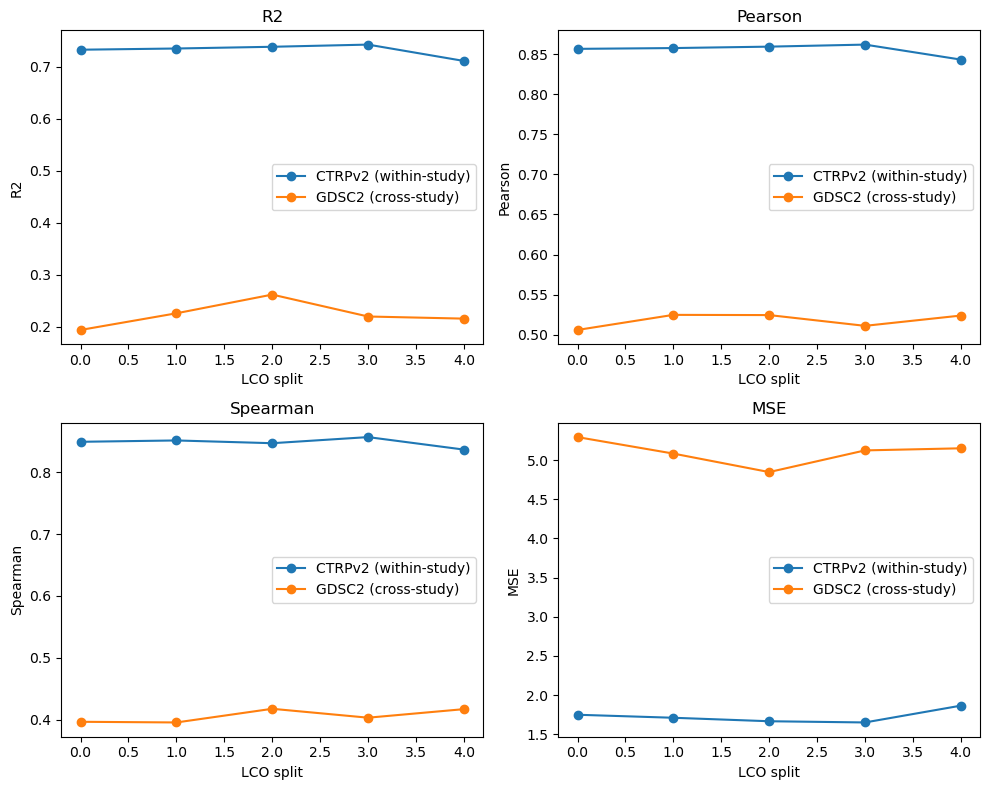

In [15]:
# cell 22 Performance across the 5 splits
# 4 panel comparison of models performance across 5 splits comparing CTRPv2 within-study against 
# GDSC2 cross-study.
# Graphs look at model consistency across the 5 LCO splits between CTRPv2 and GDSC2
# Performance drops when moving from CTRPv2 → GDSC2

import matplotlib.pyplot as plt

metrics_to_plot = ["R2", "Pearson", "Spearman", "MSE"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    ax.plot(within_df.index, within_df[metric], marker="o", label="CTRPv2 (within-study)")
    ax.plot(cross_df.index, cross_df[metric], marker="o", label="GDSC2 (cross-study)")
    ax.set_title(metric)
    ax.set_xlabel("LCO split")
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()

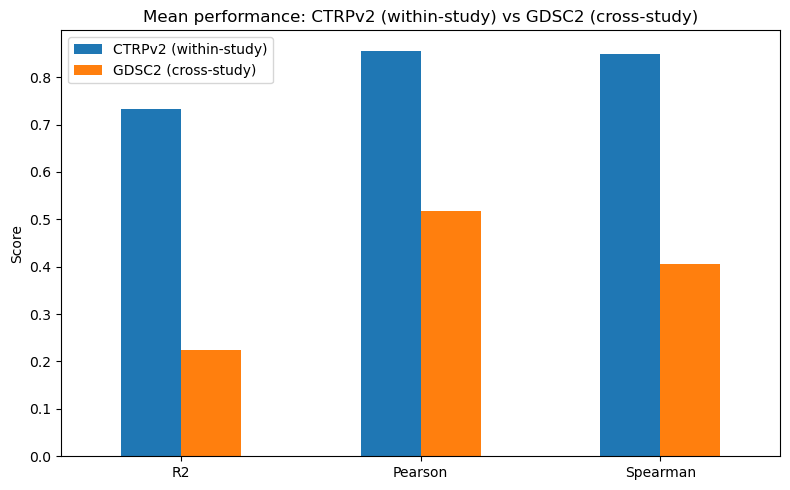

,CTRPv2 (within-study),GDSC2 (cross-study)
R2,0.731952,0.223291
Pearson,0.855906,0.517940
Spearman,0.848179,0.405803


In [16]:
# cell 23 CTRPv2 vs GDSC2 comparison
# calculates the average performance across all 5 LCO splits for each dataset
# On average, how well does my Random Forest perform within CTRPv2 compared with its performance 
# on the completely external GDSC2 dataset?


comparison_df = pd.DataFrame({
    "CTRPv2 (within-study)": within_df[["R2", "Pearson", "Spearman"]].mean(),
    "GDSC2 (cross-study)": cross_df[["R2", "Pearson", "Spearman"]].mean(),
})

comparison_df.plot(kind="bar", figsize=(8, 5))

plt.title("Mean performance: CTRPv2 (within-study) vs GDSC2 (cross-study)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

comparison_df

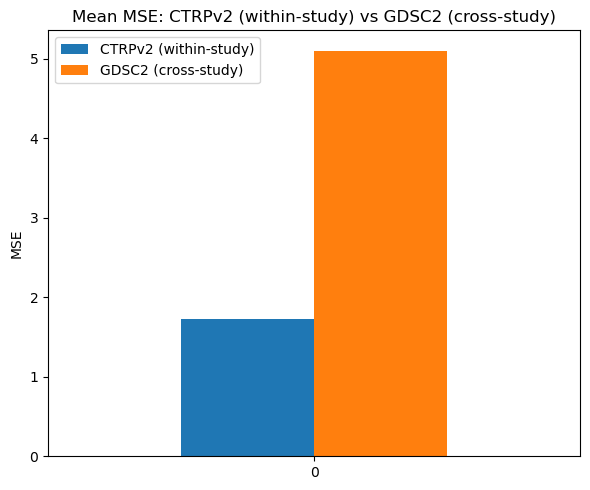

,CTRPv2 (within-study),GDSC2 (cross-study)
0,1.727688,5.100255


In [17]:
# cell 24 separate MSE comparison averaged across the 5 LCO splits. Lower MSE = better prediction.

mse_comparison_df = pd.DataFrame({
    "CTRPv2 (within-study)": [within_df["MSE"].mean()],
    "GDSC2 (cross-study)": [cross_df["MSE"].mean()],
})

mse_comparison_df.plot(kind="bar", figsize=(6, 5))

plt.title("Mean MSE: CTRPv2 (within-study) vs GDSC2 (cross-study)")
plt.ylabel("MSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

mse_comparison_df
